# Inspection of The Results

After all the experiments were ran, it is time to inspect and analyze the outcome. There will be 3 parts to that:
1. General inspection of the coverage and regularity measures. At this step, the obtained values will be analyzed, which includes their distribution, correlation, gap between the type and the token variants of the measures.
2. Inspection of token against type distributions. This inspection focuses on what constraints are represented more widely token-wise in language.
3. Inspection of the extent to which the claims about the constraints made in the literature are supported by the data. That includes manual comparison of the quantifiers specified in the constraint definitions ("regularly", "mostly" etc.) and the obtained type regularity values. We concentrate on the type variant since we want to investigate the linguistic and not the usage side of the question.

## 1. General Inspection of The Coverage and Regularity Measures

Here, we load the general applicability statistics table and retrieve three things:
1. Scatter plot of coverage against regularity in two variants (type, token). This graph serves provides both distributions of the measures and relation between them.
2. Analyze the distribution of the values closer.
3. Deviation measures of the obtained results. Serves as to further describe the distributions of the values.
4. Difference between the type and the token variants of the measures. Provides an idea of the gap between the linguistic and the usage statistics.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

### 1.1. Draw Scatter Plots

In [73]:
stats_path = "../../../resources/custom/compounding/applicability_statistics/constr_statistics.tsv"

stats_all = pd.read_csv(
    stats_path,
    sep="\t",
    index_col=0,
    header=0
)

As we found out later, two of the constraints are unreliable and so we remove them from the inspection. We also drop constraints for which no data is available (semantic and lexical constraints).

In [74]:
unreliable_constr_ids = ["p2l:drv:sfx:F_#in$-en", "l2p:s|smpx_mn", "l2p:s|smpx_high_freq"]
stats = stats_all.drop(unreliable_constr_ids).dropna()
stats

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
def-0,1.000,425563.0,1.000,384759992.0,0.573,243655.0,0.605,232657466.0
p2l:decl_cl:pl:#0-0|def-0,0.123,52463.0,0.101,39049318.0,0.910,47757.0,0.793,30953757.0
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#e-0|def-0,0.182,77545.0,0.195,74919086.0,0.691,53611.0,0.686,51423356.0
p2l:decl_cl:pl:#er-0/er|def-0/er,0.056,23866.0,0.099,37991163.0,0.864,20622.0,0.766,29092638.0
p2l:decl_cl:pl:#e_uml-0|def-0,0.109,46231.0,0.134,51400096.0,0.755,34910.0,0.793,40773697.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0


Now draw the graphs.

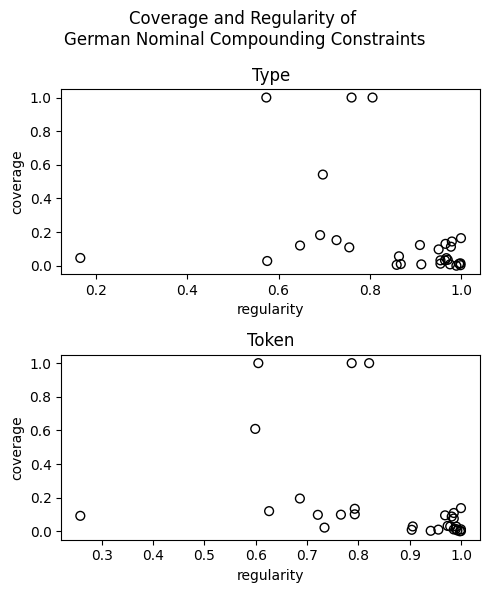

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(5, 6))

# first, type cov/reg values
axes[0].scatter(
    stats["reg_type"],
    stats["cvg_type"],
    facecolors="none",   # hollow inside
    edgecolors="black",  # outline
    s=40                 # marker size
)
axes[0].set_xlabel("regularity")
axes[0].set_ylabel("coverage")
axes[0].set_title("Type")


# first, token cov/reg values
axes[1].scatter(
    stats["reg_token"],
    stats["cvg_token"],
    facecolors="none",   # hollow inside
    edgecolors="black",  # outline
    s=40                 # marker size
)
axes[1].set_xlabel("regularity")
axes[1].set_ylabel("coverage")
axes[1].set_title("Token")


fig.suptitle(
    "Coverage and Regularity of \n"
    "German Nominal Compounding Constraints"
)

plt.tight_layout()
plt.savefig("cov_reg.png", dpi=1200)
plt.show()

### 1.2. Analyze The Distributions

Now, we check the numbers of different groups of constraints by their coverage and regularity. The groups are chosen by a visual inspection of the graph; the choice aims at a more illustrative representation of the results.

Coverage value groups.

In [84]:
stats["cvg_type"].min(), stats["cvg_type"].max()

(np.float64(0.0), np.float64(1.0))

In [85]:
stats["cvg_token"].min(), stats["cvg_token"].max()

(np.float64(0.0), np.float64(1.0))

Many of the coverage values are concentrated in the bottom of the graphs.

In [86]:
stats[(stats["cvg_type"] < 0.2) & (stats["cvg_token"] < 0.2)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#0-0|def-0,0.123,52463.0,0.101,39049318.0,0.910,47757.0,0.793,30953757.0
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#e-0|def-0,0.182,77545.0,0.195,74919086.0,0.691,53611.0,0.686,51423356.0
p2l:decl_cl:pl:#er-0/er|def-0/er,0.056,23866.0,0.099,37991163.0,0.864,20622.0,0.766,29092638.0
p2l:decl_cl:pl:#e_uml-0|def-0,0.109,46231.0,0.134,51400096.0,0.755,34910.0,0.793,40773697.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0


In [87]:
stats[(stats["cvg_type"] < 0.05) & (stats["cvg_token"] < 0.05)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0
p2l:drv:deverb_schwa$-0|def-0,0.028,11936.0,0.022,8468682.0,0.575,6869.0,0.734,6213841.0
p2l:drv:deadj_schwa$-0/en,0.010,4214.0,0.009,3445507.0,0.868,3659.0,0.904,3113944.0
p2l:drv:sfx:deverb_#en$-s,0.008,3536.0,0.011,4274706.0,0.913,3227.0,0.986,4212990.0
p2l:phon_fin:vow$-0,0.035,15031.0,0.028,10867264.0,0.971,14592.0,0.991,10767507.0


In [88]:
stats[(stats["cvg_type"] < 0.01) & (stats["cvg_token"] < 0.01)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0
l2p:e,0.008,3547.0,0.005,2082956.0,0.976,3462.0,0.993,2067815.0
l2p:e_uml,0.003,1093.0,0.002,679361.0,0.999,1092.0,1.000,679352.0
l2p:0_uml,0.000,192.0,0.000,59872.0,0.990,190.0,0.998,59743.0


Regularity value groups.

In [89]:
stats["reg_type"].min(), stats["reg_type"].max()

(np.float64(0.165), np.float64(1.0))

In [90]:
stats["reg_token"].min(), stats["reg_token"].max()

(np.float64(0.258), np.float64(1.0))

We see on the graph that there is an outlier by the regularity. Let's see the value range without it.

In [91]:
outl_reg_type_idx = stats["reg_type"].argmin().item()
stats_no_outl_reg_type = stats.iloc[list(set(range(len(stats))) - {outl_reg_type_idx})]
stats_no_outl_reg_type["reg_type"].min(), stats_no_outl_reg_type["reg_type"].max()

(np.float64(0.573), np.float64(1.0))

In [92]:
outl_reg_token_idx = stats["reg_token"].argmin().item()
stats_no_outl_reg_token = stats.iloc[list(set(range(len(stats))) - {outl_reg_token_idx})]
stats_no_outl_reg_token["reg_token"].min(), stats_no_outl_reg_token["reg_token"].max()

(np.float64(0.599), np.float64(1.0))

Now back to the groups. There is a visible shift of the values towards the right edge of the axis.

In [93]:
stats[(stats["reg_type"] > 0.9) & (stats["reg_token"] > 0.9)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:sfx-s|def-s,0.144,61278.0,0.109,41842144.0,0.980,60041.0,0.986,41243912.0
p2l:drv:sfx:deverb_#en$-s,0.008,3536.0,0.011,4274706.0,0.913,3227.0,0.986,4212990.0
p2l:phon_fin:sibilant$-0,0.097,41270.0,0.095,36573549.0,0.951,39255.0,0.969,35454042.0
p2l:phon_fin:vow$-0,0.035,15031.0,0.028,10867264.0,0.971,14592.0,0.991,10767507.0
p2l:phon_fin:F_#stressed_phon$-0,0.032,13513.0,0.029,11121251.0,0.965,13034.0,0.979,10887065.0


In [94]:
stats[(stats["reg_type"] > 0.98) & (stats["reg_token"] > 0.98)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
l2p:s|f,0.164,69825.0,0.138,53027970.0,1.000,69814.0,1.000,53025946.0
l2p:er,0.014,5881.0,0.012,4547874.0,0.999,5876.0,1.000,4546705.0
l2p:e_uml,0.003,1093.0,0.002,679361.0,0.999,1092.0,1.000,679352.0
l2p:0_uml,0.000,192.0,0.000,59872.0,0.990,190.0,0.998,59743.0


### 1.3. Compute Deviation Measures

Now, to further disclose the distribution of the values, we calculate their SDs.

In [51]:
import numpy as np

In [96]:
measure_sds = pd.DataFrame({
    "cvg": {
        "type": np.std(stats["cvg_type"]),
        "token": np.std(stats["cvg_token"])
    },
    "reg": {
        "type": np.std(stats["reg_type"]),
        "token": np.std(stats["reg_token"])
    }
})

measure_sds

,cvg,reg
type,0.293327,0.182415
token,0.297206,0.172361


### 1.4. Estimate The Difference Between The Type and The Token Variants

Here, we want to investigate how large the gap between the type and the token values for the same contrast is on average.

In [ ]:
from sklearn.metrics import mean_absolute_error

In [97]:
type_token_maes = pd.Series({
    "cvg": mean_absolute_error(stats["cvg_type"], stats["cvg_token"]),
    "reg": mean_absolute_error(stats["reg_type"], stats["reg_token"])
})

type_token_maes

cvg    0.015333
reg    0.041500
dtype: float64

## 2. Inspection of Token Against Type Distributions

TODO

## 3. Inspection of The Extent to Which the Claims About the Constraints Made in The Literature Are Supported by The Data

The following steps are to be done for final inspection:
1. Manually inspect the support level of the claims in the empirical data. For each (analyzed) constraint, record the level of support. Since the definitions are mostly vague, base the decision on commonsense judgments. For the support level, we concentrate on the type variant of the measures since we focus on the linguistic side of the question (not real usage). There are 4 levels of support:
    * Supported. Full or very close correspondence between the quantifier and the empirical data. Examples: "regular" vs 0.99, "mostly" vs 0.75.
    * Partially supported. The gap is not critical yet noticeable. Examples: "regular" vs 0.93, "tends" vs 0.6, "sometimes" vs 0.9.
    * Not supported. The discrepancy between the quantifier and the empirical data is too significant to ignore. Examples: "regular" vs 0.85, "tends" vs 0.4.
    * NA: no data available (unreliable or semantic/lexical constraints).

Note: this steps is being conducted in the file with constraints definitions, see `compounding/constraints/constraints.yaml`. While it is being now made at the time of this inspection, we cannot reflect this processes here. After this step is done, we pull the results from this file and further inspect them in detail, specifically:

2. Inspect the distribution of the support levels.
3. Manually inspect the constraints that are only partially supported by the data or not supported at all.

### 3.1. Inspection of The Support Level

Done separately in `compounding/constraints/constraints.yaml`.

### 3.2. Inspection of Support Level Distribution

Now, we read the constraint definition file for inspection.

In [70]:
import yaml

In [71]:
with open("../../constraints/constraints.yaml", encoding="utf-8") as f:
    constraints: dict = list(yaml.safe_load_all(f))[-1]["constraints"]

In [100]:
df_path = "../../../resources/custom/compounding/applicability_statistics/appl_index.tsv"

df = pd.read_csv(
    df_path,
    sep="\t",
    index_col=0,
    header=0
)

/var/folders/p7/mdc5srxs0w36vn95fwp7jq880000gn/T/ipykernel_10797/861646978.py:3: DtypeWarning: Columns (4,6,14,28,32,36,38,40,44,46,50,54,56,58,60,62,64,82,90,92,100,102,104,110) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [112]:
c_id = "p2l:drv:sfx:e_pl_sfx-0"
x = df[f"{c_id}_applies"].dropna(inplace=False)
f = x[x == False]

ind = [not comp.split("_")[0].endswith("at") for comp in f.index]
f[ind]
len(f)

327

In [83]:
c_id = "p2l:phon_fin:vow$-0"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[300:]

comp_gecodb
fee_+n_pflanze         False
solo_+s_kipper         False
melodie_+n_reigen      False
melodie_+n_reichtum    False
melodie_+n_folge       False
                       ...  
hotelier_+s_frau       False
hotelier_+s_gattin     False
hotelier_+s_verband    False
hotelier_+s_paar       False
hotelier_+s_kollege    False
Name: p2l:phon_fin:vow$-0_applies, Length: 139, dtype: object

In [5]:
c_id = "p2l:phon_fin:F_stem_#t$-s"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[7000:]

comp_gecodb
post_anschrift     False
post_stempel       False
post_kutsche       False
post_adresse       False
post_produktion    False
                   ...  
jacht_sport        False
jacht_schule       False
jacht_rennen       False
jacht_urlaub       False
jacht_eigner       False
Name: p2l:phon_fin:F_stem_#t$-s_applies, Length: 9467, dtype: object

In [136]:
c_id = "p2l:phon_fin:schwa$-en"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[10000:]

comp_gecodb
bronze_miniatur    False
bronze_lack        False
bronze_koloss      False
bronze_gesicht     False
bronze_baum        False
                   ...  
bowle_party        False
bowle_stand        False
bahre_tal          False
bahre_taler        False
bahre_bach         False
Name: p2l:phon_fin:schwa$-en_applies, Length: 7622, dtype: object

In [116]:
df[df["p2l:drv:deverb_schwa$-0|def-0_applies"].fillna(False)]

/var/folders/p7/mdc5srxs0w36vn95fwp7jq880000gn/T/ipykernel_4488/2407832081.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df["p2l:drv:deverb_schwa$-0|def-0_applies"].fillna(False)]


,def-0_is_applicable,def-0_applies,p2l:decl_cl:pl:#0-0|def-0_is_applicable,p2l:decl_cl:pl:#0-0|def-0_applies,p2l:decl_cl:pl:#s-0_is_applicable,p2l:decl_cl:pl:#s-0_applies,p2l:decl_cl:pl:#e-0|def-0_is_applicable,p2l:decl_cl:pl:#e-0|def-0_applies,p2l:decl_cl:pl:#e-0|pl_interpr-e_is_applicable,p2l:decl_cl:pl:#e-0|pl_interpr-e_applies,...,l2p:er_is_applicable,l2p:er_applies,l2p:e_uml_is_applicable,l2p:e_uml_applies,l2p:es_is_applicable,l2p:es_applies,l2p:ens_is_applicable,l2p:ens_applies,l2p:0_uml_is_applicable,l2p:0_uml_applies
comp_gecodb,,,,,,,,,,,,,,,,,,,,,
reise_ziel,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
reise_bericht,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
reise_veranstalter,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
reise_pass,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
reise_zeit,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
abhilfe_frist,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
abhilfe_vorschlag,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN
abhilfe_prüfung,True,True,False,NaN,False,NaN,False,NaN,NaN,NaN,...,False,NaN,False,NaN,NaN,NaN,NaN,NaN,False,NaN


In [99]:
t = df[df["p2l:drv:deadj_schwa$-0/en_applies"].fillna(False)]
ind = [len(comp.split("_")) == 2 for comp in t.index]
t[ind]

NameError: name 'df' is not defined

In [7]:
c_id = "p2l:tend:cmpx_phon-s|def-s"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[6000:]

comp_gecodb
musik_umsetzung        False
musik_straße           False
musik_stöpsel          False
musik_ständchen        False
musik_rahmen           False
                       ...  
archäologe_+n_kreis    False
archäologe_+n_leben    False
archäologe_+n_zunft    False
archäologe_+n_paar     False
archäologe_+n_herz     False
Name: p2l:tend:cmpx_phon-s|def-s_applies, Length: 96209, dtype: bool

In [8]:
# unreliable
c_id = "l2p:s|smpx_mn"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[1600:]

comp_gecodb
geburt_+s_stadt         False
geburt_+s_urkunde       False
geburt_+s_jahr          False
geburt_+s_gewicht       False
geburt_+s_termin        False
                        ...  
parität_+s_änderung     False
parität_+s_kurs         False
parität_+s_klausel      False
parität_+s_forderung    False
parität_+s_modell       False
Name: l2p:s|smpx_mn_applies, Length: 1613, dtype: object

In [9]:
c_id = "p2l:drv:sfx:sfx-s|def-s"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[200:]

comp_gecodb
forschung_stand            False
forschung_sund             False
forschung_stelle           False
forschung_ergebnis         False
forschung_schiff           False
                           ...  
kuriosität_+en_ecke        False
kuriosität_+en_wert        False
kuriosität_+en_liste       False
kuriosität_+en_markt       False
kuriosität_+en_künstler    False
Name: p2l:drv:sfx:sfx-s|def-s_applies, Length: 1037, dtype: object

In [ ]:
c_id = "p2l:drv:deadj_schwa$-0/en"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[0:]

comp_gecodb
liebe_+s_geschichte     False
liebe_+s_beziehung      False
liebe_+s_erklärung      False
liebe_+s_paar           False
liebe_+s_lied           False
                        ...  
liebe_+s_sabotage       False
liebe_+s_melancholie    False
liebe_+s_interview      False
liebe_+s_höhe           False
liebe_+s_flaute         False
Name: p2l:drv:deadj_schwa$-0/en_applies, Length: 555, dtype: object

In [11]:
c_id = "l2p:0_uml"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[0:]

comp_gecodb
wasser_+=_land    False
lager_+=_rispe    False
Name: l2p:0_uml_applies, dtype: object

In [12]:
c_id = "l2p:e_uml"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[0:]

comp_gecodb
staub_+=e_mittel    False
Name: l2p:e_uml_applies, dtype: object

In [13]:
c_id = "l2p:er"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[0:]

comp_gecodb
vorbild_+=er_sammlung       False
ding_+=er_mann              False
altertum_+=er_verwaltung    False
altertum_+=er_sammlung      False
altertum_+=er_behörde       False
Name: l2p:er_applies, dtype: object

In [97]:
c_id = "l2p:e"
x = df[f"{c_id}_applies"].dropna(inplace=False)
len(x[x == False])#.iloc[70:]

85

In [15]:
c_id = "l2p:n"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[700:]

comp_gecodb
nummer_+n_schema         False
nummer_+n_feld           False
nummer_+n_kombination    False
nummer_+n_schalter       False
nummer_+n_ausgabe        False
                         ...  
aster_+n_blüte           False
aster_+n_art             False
aster_+n_sorte           False
aster_+n_turnier         False
aster_+n_platz           False
Name: l2p:n_applies, Length: 361, dtype: object

In [16]:
c_id = "p2l:decl_cl:pl:#0-0|def-0"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[920:]

comp_gecodb
unternehmen_+s_kultur           False
unternehmen_+s_berater          False
unternehmen_+s_bereich          False
unternehmen_+s_kommunikation    False
unternehmen_+s_gründung         False
                                ...  
pater_+s_bach                   False
pater_+s_kirche                 False
pater_+s_haus                   False
pater_+s_wald                   False
pater_+s_gasse                  False
Name: p2l:decl_cl:pl:#0-0|def-0_applies, Length: 3786, dtype: object

In [17]:
c_id = "p2l:drv:sfx:0_pl_sfx-0"
x = df[f"{c_id}_applies"].dropna(inplace=False)
x[x == False].iloc[200:]

comp_gecodb
alter_+s_abstufung      False
alter_+s_vorstellung    False
alter_+s_sportler       False
alter_+s_phänomen       False
alter_+s_verschleiß     False
                        ...  
pächter_+s_tochter      False
freier_+s_fuß           False
freier_+s_mann          False
freier_+s_berg          False
freier_+s_leben         False
Name: p2l:drv:sfx:0_pl_sfx-0_applies, Length: 414, dtype: object